In [29]:
!pip install category_encoders


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.9 MB/s eta 0:00:00


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [42]:
df = pd.read_csv('dataset.csv')

In [43]:
df_shuffled = df.sample(frac=1).reset_index(drop=True)

In [44]:
df_shuffled.head()

,primary_material,recycled_percentage,dye_type,chemical_finish,manufacturing_country,shipping_distance_km,has_oeko_tex,is_fair_trade,is_b_corp,est_carbon_emission_kg,eco_score
0,Hemp,5,Natural,False,Australia,8700,True,True,False,7.70,86.20
1,Recycled Polyester,75,Azo-free,True,Vietnam,4091,False,False,True,9.24,91.90
2,Organic Cotton,0,Natural,False,USA,1686,False,True,False,2.58,82.14
3,Hemp,0,Unknown,False,India,399,False,True,False,2.08,96.68
4,Recycled Polyester,66,Azo-free,False,Vietnam,7511,False,False,True,6.61,70.03


       primary_material  recycled_percentage dye_type chemical_finish  \
count              5641          5641.000000     5641            5641   
unique                6                  NaN        4               2   
top                Hemp                  NaN  Natural           False   
freq                960                  NaN     1482            3166   
mean                NaN            18.301188      NaN             NaN   
std                 NaN            25.795621      NaN             NaN   
min                 NaN             0.000000      NaN             NaN   
25%                 NaN             4.000000      NaN             NaN   
50%                 NaN             9.000000      NaN             NaN   
75%                 NaN            14.000000      NaN             NaN   
max                 NaN           100.000000      NaN             NaN   

       manufacturing_country  shipping_distance_km has_oeko_tex is_fair_trade  \
count                   5641           564

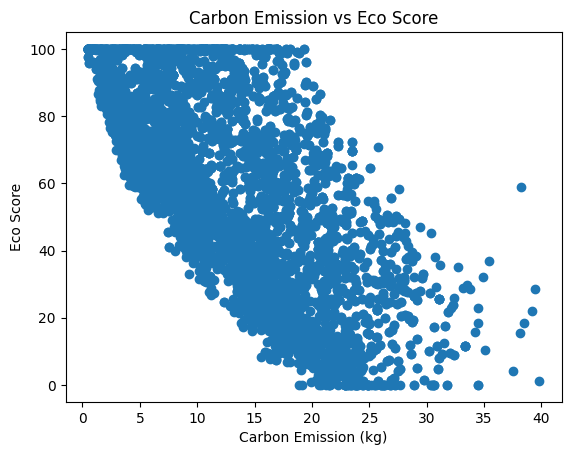

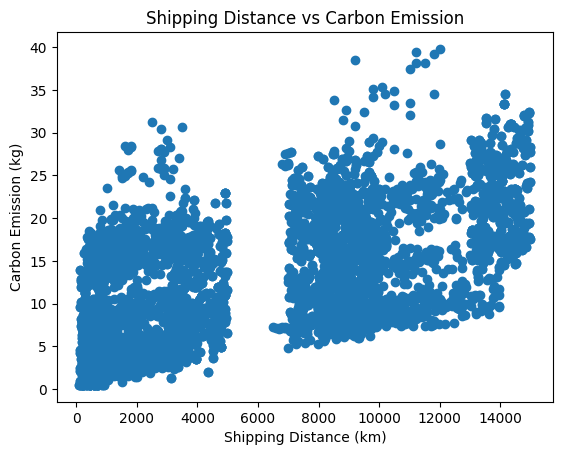

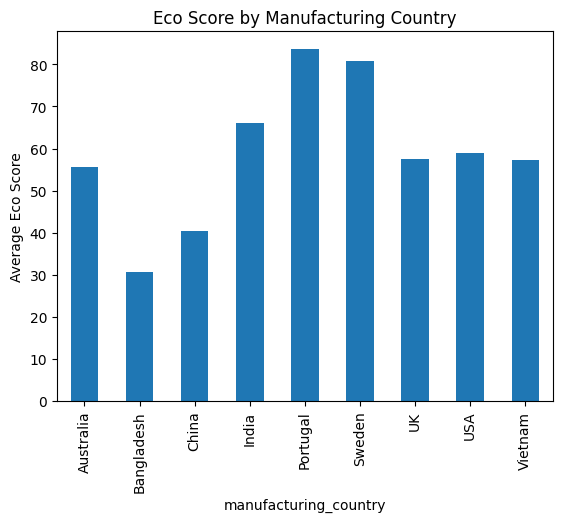

In [45]:
# Basic analysis

summary = df.describe(include='all')
print(summary)

# Plot 1: Carbon Emission vs Eco Score
plt.figure()
plt.scatter(df["est_carbon_emission_kg"], df["eco_score"])
plt.xlabel("Carbon Emission (kg)")
plt.ylabel("Eco Score")
plt.title("Carbon Emission vs Eco Score")
plt.show()

# Plot 2: Shipping Distance vs Carbon Emission
plt.figure()
plt.scatter(df["shipping_distance_km"], df["est_carbon_emission_kg"])
plt.xlabel("Shipping Distance (km)")
plt.ylabel("Carbon Emission (kg)")
plt.title("Shipping Distance vs Carbon Emission")
plt.show()

# Plot 3: Average Eco Score by Country
avg_score = df.groupby("manufacturing_country")["eco_score"].mean()
plt.figure()
avg_score.plot(kind='bar')
plt.ylabel("Average Eco Score")
plt.title("Eco Score by Manufacturing Country")
plt.show()

##Data preprocessing


In [46]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import category_encoders as ce

# 1. Convert Booleans to Integers
bool_cols = ['chemical_finish', 'has_oeko_tex', 'is_fair_trade', 'is_b_corp']
for col in bool_cols:
    df_shuffled[col] = df_shuffled[col].astype(int)

# 2. Target Encoding for Categories
# We will encode 'manufacturing_country' and 'primary_material' based on the carbon emission target.
# handle_unknown='value' tells it to use the global mean for brand new countries/materials.
cat_cols = ['dye_type', 'primary_material', 'manufacturing_country']

target_encoder = ce.TargetEncoder(cols=cat_cols, handle_unknown='value')

# Fit the encoder on the features and ONE of your targets (e.g., carbon emissions)
df_shuffled[cat_cols] = target_encoder.fit_transform(df_shuffled[cat_cols], df_shuffled['est_carbon_emission_kg'])

# 3. Feature Scaling
scaler = StandardScaler()
df_shuffled['shipping_distance_km'] = scaler.fit_transform(df_shuffled[['shipping_distance_km']])

# 4. Define Features and Targets
X = df_shuffled.drop(columns=['est_carbon_emission_kg', 'eco_score'])
y_carbon = df_shuffled['est_carbon_emission_kg']
y_eco = df_shuffled['eco_score']

print(X.head())

   primary_material  recycled_percentage   dye_type  chemical_finish  \
0          7.848083                    5  11.577281                0   
1          9.405225                   75  11.814787                1   
2          8.647979                    0  11.577281                0   
3          7.848083                    0  14.012965                0   
4          9.405225                   66  11.814787                0   

   manufacturing_country  shipping_distance_km  has_oeko_tex  is_fair_trade  \
0              15.561868              0.554949             1              1   
1              12.398756             -0.464414             0              0   
2              15.956513             -0.996323             0              1   
3               7.738328             -1.280966             0              1   
4              12.398756              0.291980             0              0   

   is_b_corp  
0          0  
1          1  
2          0  
3          0  
4          1  


In [47]:
X

,primary_material,recycled_percentage,dye_type,chemical_finish,manufacturing_country,shipping_distance_km,has_oeko_tex,is_fair_trade,is_b_corp
0,7.848083,5,11.577281,0,15.561868,0.554949,1,1,0
1,9.405225,75,11.814787,1,12.398756,-0.464414,0,0,1
2,8.647979,0,11.577281,0,15.956513,-0.996323,0,1,0
3,7.848083,0,14.012965,0,7.738328,-1.280966,0,1,0
4,9.405225,66,11.814787,0,12.398756,0.291980,0,0,1
...,...,...,...,...,...,...,...,...,...
5636,9.405225,86,11.814787,0,8.205434,-1.249118,1,0,1
5637,8.647979,2,11.814787,0,15.956513,-1.096512,0,0,0
5638,8.647979,0,15.172099,1,12.398756,0.261680,0,0,0
5639,9.405225,89,11.814787,1,7.738328,-1.297775,0,0,0


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [48]:
y_carbon

,est_carbon_emission_kg
0,7.70
1,9.24
2,2.58
3,2.08
4,6.61
...,...
5636,6.20
5637,3.08
5638,9.21
5639,5.15


In [49]:
y_eco

,eco_score
0,86.20
1,91.90
2,82.14
3,96.68
4,70.03
...,...
5636,78.90
5637,74.62
5638,43.57
5639,88.33


In [50]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, pd.concat([y_carbon, y_eco], axis=1), test_size=0.2, random_state=42
)

# Train a single model for both targets
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict both at once
predictions = rf_model.predict(X_test) # Returns an array like [[18.5, 2.8], [9.2, 10.0], ...]

In [52]:
predictions[:10]

array([[19.0122, 50.0992],
       [25.1351, 37.2825],
       [12.58  , 76.17  ],
       [16.187 , 37.7924],
       [14.4986, 29.015 ],
       [ 4.2867, 92.6951],
       [21.3005, 53.3601],
       [ 8.2276, 78.8869],
       [14.2687, 90.351 ],
       [15.5018, 23.7124]])

In [53]:
y_train

,est_carbon_emission_kg,eco_score
3751,0.50,100.00
322,20.95,72.30
4089,1.77,87.40
2951,7.96,73.92
5064,28.43,19.72
...,...,...
3772,7.90,64.48
5191,17.50,24.50
5226,23.71,59.83
5390,21.88,9.81


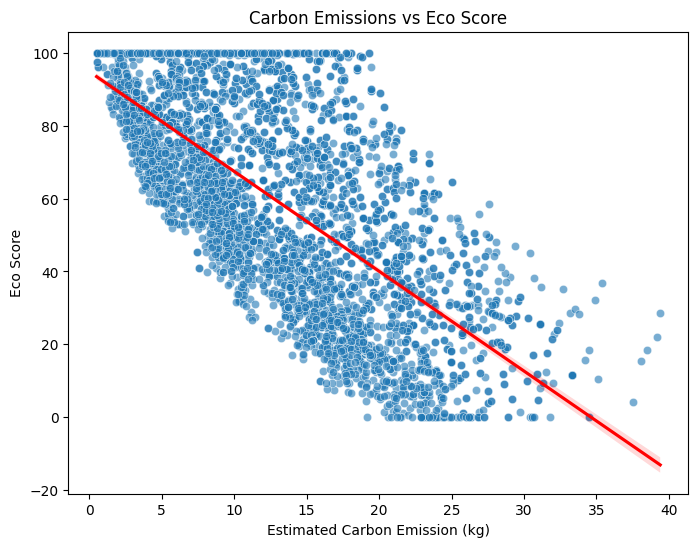

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your dataframe is called df
# with columns: 'est_carbon_emission_kg' and 'eco_score'

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=y_train,
    x="est_carbon_emission_kg",
    y="eco_score",
    alpha=0.6
)

# Add regression/trend line
sns.regplot(
    data=y_train,
    x="est_carbon_emission_kg",
    y="eco_score",
    scatter=False,
    color="red"
)

plt.title("Carbon Emissions vs Eco Score")
plt.xlabel("Estimated Carbon Emission (kg)")
plt.ylabel("Eco Score")
plt.show()


Text(0, 0.5, 'Eco Score')

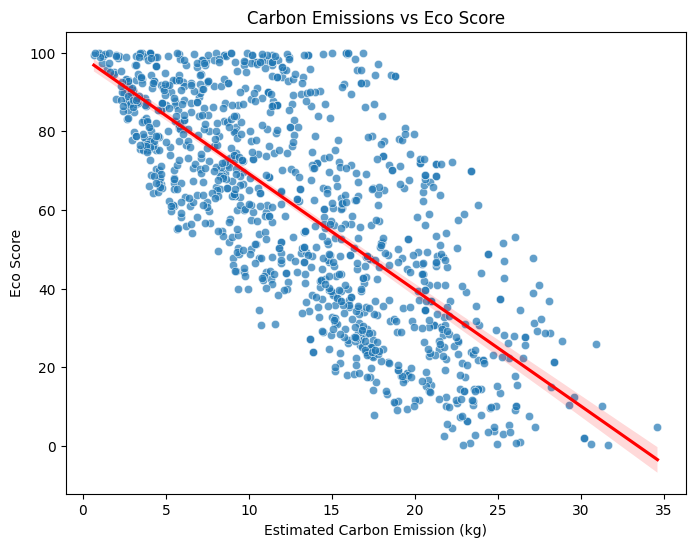

In [57]:
emissions = predictions[:,0]
eco_scores = predictions[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(x=emissions, y=eco_scores, alpha=0.7)

# Add regression line
sns.regplot(x=emissions, y=eco_scores, scatter=False, color="red")

plt.title("Carbon Emissions vs Eco Score")
plt.xlabel("Estimated Carbon Emission (kg)")
plt.ylabel("Eco Score")

In [58]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# 1. Combine your two targets into a single array
y_combined = pd.concat([y_carbon, y_eco], axis=1).values

# 2. Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y_combined, test_size=0.2, random_state=42
)

# 3. Convert arrays to PyTorch Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# 4. Create DataLoaders for batching (batch size of 32 is a good default)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [59]:
class EcoScoreModel(nn.Module):
    def __init__(self, input_features):
        super(EcoScoreModel, self).__init__()
        # Hidden Layer 1: Takes your features and expands them
        self.layer1 = nn.Linear(input_features, 64)
        # Hidden Layer 2: Compresses them to find core patterns
        self.layer2 = nn.Linear(64, 32)
        # Output Layer: Outputs EXACTLY 2 numbers (carbon, eco_score)
        self.output_layer = nn.Linear(32, 2)

        # Activation function adds non-linearity
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.output_layer(x)
        return x

# Instantiate the model based on however many columns are in X
input_dim = X.shape[1]
model = EcoScoreModel(input_features=input_dim)

In [68]:
# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop
epochs = 100

for epoch in range(epochs):
    model.train() # Set model to training mode
    total_loss = 0

    for batch_X, batch_y in train_loader:
        # 1. Clear old gradients
        optimizer.zero_grad()

        # 2. Forward pass: compute predictions
        predictions = model(batch_X)

        # 3. Calculate the loss
        loss = criterion(predictions, batch_y)

        # 4. Backward pass: compute gradients
        loss.backward()

        # 5. Update weights
        optimizer.step()

        total_loss += loss.item()

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}, Accuracy: {}')

Epoch 10/100, Loss: 30.9455
Epoch 20/100, Loss: 31.2729
Epoch 30/100, Loss: 31.3045
Epoch 40/100, Loss: 30.6438
Epoch 50/100, Loss: 30.6676
Epoch 60/100, Loss: 30.3957
Epoch 70/100, Loss: 30.3804
Epoch 80/100, Loss: 29.4529
Epoch 90/100, Loss: 29.9905
Epoch 100/100, Loss: 29.5363


In [69]:
# Save the trained weights
FILE_NAME = "eco_model_weights.pth"
torch.save(model.state_dict(), FILE_NAME)
print(f"Model saved to {FILE_NAME}")

Model saved to eco_model_weights.pth


In [70]:
# 1. Initialize the same model structure
loaded_model = EcoScoreModel(input_features=input_dim)

# 2. Load the weights
loaded_model.load_state_dict(torch.load("eco_model_weights.pth"))

# 3. Set to evaluation mode (crucial for inference!)
loaded_model.eval()

# Example prediction on new data
with torch.no_grad():
    sample_data = X_test_tensor[0].unsqueeze(0) # Taking one row for testing
    prediction = loaded_model(sample_data)
    print(f"Predicted Carbon & Eco Score: {prediction.numpy()}")

Predicted Carbon & Eco Score: [[15.874584 54.269276]]


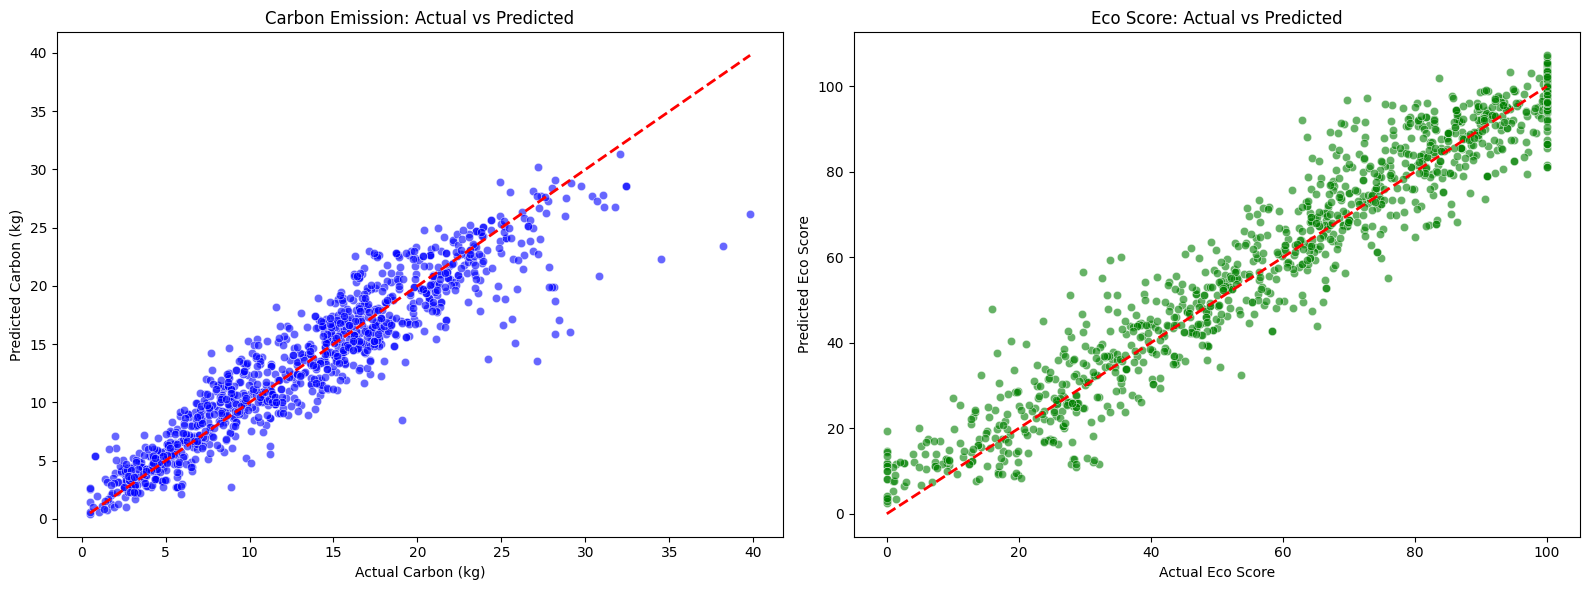

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get predictions for the ENTIRE test set
model.eval()
with torch.no_grad():
    test_predictions = model(X_test_tensor).numpy()
    test_actuals = y_test_tensor.numpy()

# Extract individual columns for easier plotting
actual_carbon = test_actuals[:, 0]
pred_carbon = test_predictions[:, 0]

actual_eco = test_actuals[:, 1]
pred_eco = test_predictions[:, 1]

# 2. Set up the plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Carbon Emissions ---
sns.scatterplot(x=actual_carbon, y=pred_carbon, ax=axes[0], alpha=0.6, color='blue')
# Draw the "Perfect Prediction" diagonal line
axes[0].plot([actual_carbon.min(), actual_carbon.max()],
             [actual_carbon.min(), actual_carbon.max()],
             'r--', lw=2)
axes[0].set_title('Carbon Emission: Actual vs Predicted')
axes[0].set_xlabel('Actual Carbon (kg)')
axes[0].set_ylabel('Predicted Carbon (kg)')

# --- Plot 2: Eco Score ---
sns.scatterplot(x=actual_eco, y=pred_eco, ax=axes[1], alpha=0.6, color='green')
# Draw the "Perfect Prediction" diagonal line
axes[1].plot([actual_eco.min(), actual_eco.max()],
             [actual_eco.min(), actual_eco.max()],
             'r--', lw=2)
axes[1].set_title('Eco Score: Actual vs Predicted')
axes[1].set_xlabel('Actual Eco Score')
axes[1].set_ylabel('Predicted Eco Score')

plt.tight_layout()
plt.show()

In [76]:
X_test_tensor[0]

tensor([13.1889,  5.0000, 11.8148,  1.0000, 19.0372,  0.5992,  1.0000,  0.0000,
         0.0000])

In [77]:
import joblib

# Save the encoder and scaler
joblib.dump(target_encoder, 'target_encoder.pkl')
joblib.dump(scaler, 'distance_scaler.pkl')

['distance_scaler.pkl']

In [78]:
import joblib
import pandas as pd
import torch

# Load these ONCE when your app/server starts
target_encoder = joblib.load('target_encoder.pkl')
distance_scaler = joblib.load('distance_scaler.pkl')
# loaded_model = ... (Load your PyTorch model here as well)

In [79]:
def preprocess_user_input(raw_user_data):
    """
    Takes a dictionary of raw user inputs and converts it into a PyTorch tensor.
    """
    # 1. Convert the single user input into a Pandas DataFrame (1 row)
    # The encoder and scaler expect DataFrames, not raw dictionaries
    df = pd.DataFrame([raw_user_data])

    # 2. Convert Booleans to Integers (True/False -> 1/0)
    bool_cols = ['chemical_finish', 'has_oeko_tex', 'is_fair_trade', 'is_b_corp']
    for col in bool_cols:
        # Using int() ensures it becomes 1 or 0
        df[col] = df[col].astype(int)

    # 3. Apply Target Encoding to Text Categories
    # transform() uses the rules it learned during training.
    # If a new material/country is entered, it safely applies the global average.
    cat_cols = ['primary_material', 'dye_type', 'manufacturing_country']
    df[cat_cols] = target_encoder.transform(df[cat_cols])

    # 4. Scale the Distance
    # transform() applies the exact mean and variance from your training data
    df[['shipping_distance_km']] = distance_scaler.transform(df[['shipping_distance_km']])

    # 5. Ensure the columns are in the EXACT SAME ORDER as they were during training
    # This is critical. If the order gets mixed up, the model will output garbage.
    expected_order = [
        'primary_material', 'recycled_percentage', 'dye_type',
        'chemical_finish', 'manufacturing_country', 'shipping_distance_km',
        'has_oeko_tex', 'is_fair_trade', 'is_b_corp'
    ]
    df = df[expected_order]

    # 6. Convert to PyTorch Tensor
    input_tensor = torch.tensor(df.values, dtype=torch.float32)

    return input_tensor

In [80]:
# The raw data exactly as a user might type it into your frontend
user_payload = {
    'primary_material': 'Hemp',
    'recycled_percentage': 5.0,
    'dye_type': 'Natural',
    'chemical_finish': True,
    'manufacturing_country': 'USA',
    'shipping_distance_km': 1765,
    'has_oeko_tex': True,
    'is_fair_trade': False,
    'is_b_corp': False
}

# 1. Process the raw data
ready_tensor = preprocess_user_input(user_payload)

# 2. Feed it to the model
with torch.no_grad():
    prediction = loaded_model(ready_tensor)

print("Formatted Tensor:", ready_tensor)
print("Predicted Carbon & Eco Score:", prediction.numpy())

Formatted Tensor: tensor([[ 7.8481,  5.0000, 11.5773,  1.0000, 15.9565, -0.9789,  1.0000,  0.0000,
          0.0000]])
Predicted Carbon & Eco Score: [[ 3.9620628 84.70198  ]]
